# Task 4

## Task: Banknote Authentication Classification

In this task, you will work with the dataset provided in the file **`data_banknote_authentication.csv`**

Your objective is to build and evaluate classification models to predict the authenticity of banknotes.

You should:

- Load and explore the dataset.
- Build two classification models:
  - **Decision Tree**
  - **Random Forest**
- Use **GridSearchCV** to optimize the hyperparameters of each model.
- Evaluate the performance of both models using:
  - **Confusion Matrix**
  - **Classification Report**

Finally, **compare the performance of the two models** and discuss which model performs better for this dataset.

## 1. Imports and Loading the Dataset

In [16]:
# Basic libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Model selection and evaluation
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# Models
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Optional: make plots look cleaner
sns.set_style("whitegrid")

In [17]:
# Load the dataset
df = pd.read_csv("data_banknote_authentication.csv")

df.head()

,Variance_Wavelet,Skewness_Wavelet,Curtosis_Wavelet,Image_Entropy,Class
0,3.62160,8.6661,-2.8073,-0.44699,0
1,4.54590,8.1674,-2.4586,-1.46210,0
2,3.86600,-2.6383,1.9242,0.10645,0
3,3.45660,9.5228,-4.0112,-3.59440,0
4,0.32924,-4.4552,4.5718,-0.98880,0


## 2. Exploring the Data

In [18]:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1372 entries, 0 to 1371
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Variance_Wavelet  1372 non-null   float64
 1   Skewness_Wavelet  1372 non-null   float64
 2   Curtosis_Wavelet  1372 non-null   float64
 3   Image_Entropy     1372 non-null   float64
 4   Class             1372 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 53.7 KB


In [19]:
# Statistical summary
df.describe()

,Variance_Wavelet,Skewness_Wavelet,Curtosis_Wavelet,Image_Entropy,Class
count,1372.000000,1372.000000,1372.000000,1372.000000,1372.000000
mean,0.433735,1.922353,1.397627,-1.191657,0.444606
std,2.842763,5.869047,4.310030,2.101013,0.497103
min,-7.042100,-13.773100,-5.286100,-8.548200,0.000000
25%,-1.773000,-1.708200,-1.574975,-2.413450,0.000000
50%,0.496180,2.319650,0.616630,-0.586650,0.000000
75%,2.821475,6.814625,3.179250,0.394810,1.000000
max,6.824800,12.951600,17.927400,2.449500,1.000000


In [20]:
# Check class distribution
df['Class'].value_counts()

Class
0    762
1    610
Name: count, dtype: int64

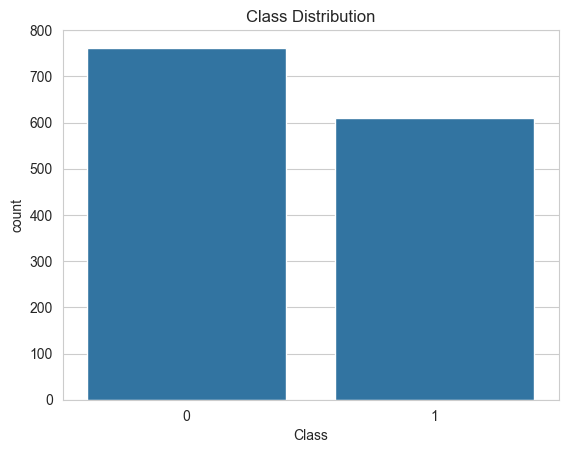

In [21]:
# Visualize class distribution
sns.countplot(data=df, x='Class')
plt.title("Class Distribution")
plt.show()

## 3. Train-Test Split

In [22]:
# Features and target
X = df.drop('Class', axis=1)
y = df['Class']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (960, 4)
X_test shape: (412, 4)
y_train shape: (960,)
y_test shape: (412,)


## 4. Decision Tree with GridSearchCV

In [23]:
# Create the base Decision Tree model
dt = DecisionTreeClassifier(random_state=42)

# Hyperparameter grid for tuning
dt_param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 3, 5, 7, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# GridSearchCV for Decision Tree
dt_grid = GridSearchCV(
    estimator=dt,
    param_grid=dt_param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

# Train the model
dt_grid.fit(X_train, y_train)

#  parameters and  CV score
print("Best Decision Tree Parameters:", dt_grid.best_params_)
print("Best Decision Tree CV Score:", dt_grid.best_score_)

Best Decision Tree Parameters: {'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 10}
Best Decision Tree CV Score: 0.990625


In [24]:
#  Decision Tree model
best_dt = dt_grid.best_estimator_

# Predictions on the test set
dt_preds = best_dt.predict(X_test)

# Accuracy
dt_accuracy = accuracy_score(y_test, dt_preds)
print("Decision Tree Test Accuracy:", dt_accuracy)

Decision Tree Test Accuracy: 0.9927184466019418


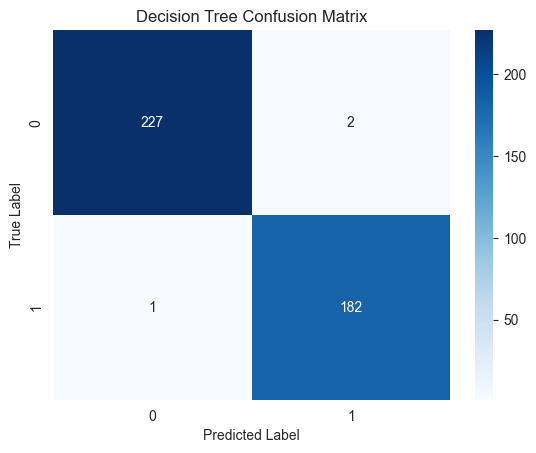

Decision Tree Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99       229
           1       0.99      0.99      0.99       183

    accuracy                           0.99       412
   macro avg       0.99      0.99      0.99       412
weighted avg       0.99      0.99      0.99       412



In [25]:
# Confusion Matrix for Decision Tree
dt_cm = confusion_matrix(y_test, dt_preds)

sns.heatmap(dt_cm, annot=True, fmt='d', cmap='Blues')
plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

print("Decision Tree Classification Report:")
print(classification_report(y_test, dt_preds))

## 5. Random Forest with GridSearchCV

In [26]:
# Create the base Random Forest model
rf = RandomForestClassifier(random_state=42)

# Hyperparameter grid for tuning
rf_param_grid = {
    'n_estimators': [50, 100, 200],
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

# GridSearchCV for Random Forest
rf_grid = GridSearchCV(
    estimator=rf,
    param_grid=rf_param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

# Train the model
rf_grid.fit(X_train, y_train)

# Best parameters and best CV score
print("Best Random Forest Parameters:", rf_grid.best_params_)
print("Best Random Forest CV Score:", rf_grid.best_score_)

Best Random Forest Parameters: {'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best Random Forest CV Score: 0.9958333333333332


In [27]:
#  Random Forest model
best_rf = rf_grid.best_estimator_

# Predictions on the test set
rf_preds = best_rf.predict(X_test)

# Accuracy
rf_accuracy = accuracy_score(y_test, rf_preds)
print("Random Forest Test Accuracy:", rf_accuracy)

Random Forest Test Accuracy: 0.9951456310679612


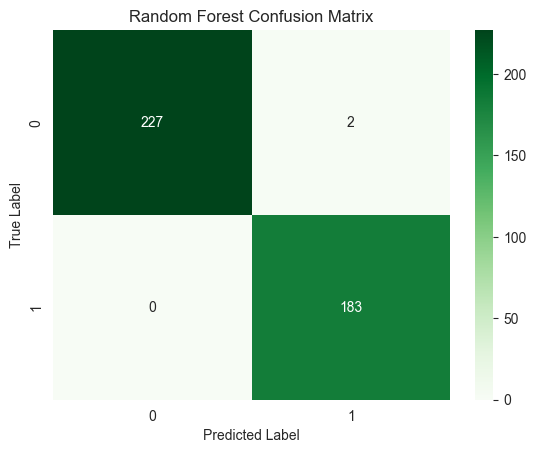

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      1.00       229
           1       0.99      1.00      0.99       183

    accuracy                           1.00       412
   macro avg       0.99      1.00      1.00       412
weighted avg       1.00      1.00      1.00       412



In [28]:
# Confusion Matrix for Random Forest
rf_cm = confusion_matrix(y_test, rf_preds)

sns.heatmap(rf_cm, annot=True, fmt='d', cmap='Greens')
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

print("Random Forest Classification Report:")
print(classification_report(y_test, rf_preds))

## 6. Final Comparison

In [29]:
# Compare both models in a small summary table
comparison_df = pd.DataFrame({
    'Model': ['Decision Tree', 'Random Forest'],
    'Test Accuracy': [dt_accuracy, rf_accuracy]
})

comparison_df.sort_values(by='Test Accuracy', ascending=False)

,Model,Test Accuracy
1,Random Forest,0.995146
0,Decision Tree,0.992718


## 7. Conclusion


- Both models were trained on the same dataset and evaluated on the same test set.
- **Decision Tree** is simple and easy to interpret, but it may overfit the training data if not tuned properly.
- **Random Forest** combines many decision trees, which usually improves generalization and reduces overfitting.

### Final Conclusion
After comparing the test accuracy, confusion matrix, and classification report of both models:

- The model with the **higher test accuracy** and **better precision, recall and F1-score** should be considered the better model for this dataset.
- In most cases for this task, **Random Forest** is expected to perform better because ensemble methods are usually more robust than a single decision tree.

In [30]:
print("DT Train Accuracy:", best_dt.score(X_train, y_train))
print("DT Test Accuracy:", best_dt.score(X_test, y_test))

print("RF Train Accuracy:", best_rf.score(X_train, y_train))
print("RF Test Accuracy:", best_rf.score(X_test, y_test))

DT Train Accuracy: 1.0
DT Test Accuracy: 0.9927184466019418
RF Train Accuracy: 1.0
RF Test Accuracy: 0.9951456310679612


Although both models achieved very high accuracy, this does not necessarily indicate overfitting. The dataset is relatively simple and well-structured, allowing models to generalize effectively. By comparing training and testing accuracy, we observed only a small difference, which indicates good generalization rather than overfitting. Additionally, Random Forest reduces overfitting by averaging multiple trees.